# Camera Preprocessing Check

`eda v2`에서 확인한 front 카메라 도메인 차이를 줄이기 위해, 이 노트북은 `train front` 이미지를 `dev+test front`의 체커보드 소실점 위치와 체커 간격에 맞추는 전처리를 점검합니다. 체커보드가 안 잡히는 샘플은 기존 원근/거리 fallback으로 처리합니다.

핵심 목표
- front 시점 카메라 proxy를 다시 추출하거나 캐시에서 로드
- `train -> dev+test` quantile mapping 기반 목표 분포를 역산
- 체커보드 소실점/간격 기반 homography 보정 적용
- 전체 샘플에 대해 보정본을 저장하고, 마지막에 10개 샘플을 시각화

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

SRC_DIR = ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from camera_preprocessing import (
    DEFAULT_EVAL_CSV,
    DEFAULT_FEATURE_CSV,
    DEFAULT_PLAN_CSV,
    DEFAULT_RENDER_DIR,
    DEFAULT_RENDER_MANIFEST_CSV,
    FRONT_CAMERA_METRICS,
    build_front_camera_plan,
    catalog_image_rows,
    evaluate_camera_plan,
    extract_camera_features,
    read_rgb,
    render_camera_adjusted_dataset,
    summarize_gap,
)

print({
    'root': str(ROOT),
    'feature_csv': str(DEFAULT_FEATURE_CSV),
    'plan_csv': str(DEFAULT_PLAN_CSV),
    'render_dir': str(DEFAULT_RENDER_DIR),
})

{'root': '/media/hdd0/whyz/structure-stability', 'feature_csv': '/media/hdd0/whyz/structure-stability/outputs/eda_preprocessing/camera_features.csv', 'plan_csv': '/media/hdd0/whyz/structure-stability/outputs/eda_preprocessing/camera_plan.csv', 'render_dir': '/media/hdd0/whyz/structure-stability/outputs/preprocessed_camera'}


In [2]:
# Feature cache: 전체 이미지 feature를 다시 계산하거나 기존 캐시를 재사용하는 셀
USE_CACHE = True

if USE_CACHE and DEFAULT_FEATURE_CSV.exists():
    feature_df = pd.read_csv(DEFAULT_FEATURE_CSV)
else:
    image_df = catalog_image_rows()
    feature_df = extract_camera_features(image_df)
    DEFAULT_FEATURE_CSV.parent.mkdir(parents=True, exist_ok=True)
    feature_df.to_csv(DEFAULT_FEATURE_CSV, index=False)

image_df = catalog_image_rows()
front_df = feature_df.query('view == "front"').copy()
display(front_df.groupby('split')[FRONT_CAMERA_METRICS].agg(['mean', 'median', 'std']).round(4))

vp_pitch_proxy                 structure_bbox_h                
                mean  median     std             mean  median     std
split                                                                
dev           0.3952  0.3856  0.0461           0.4755  0.4557  0.1574
test          0.3949  0.3942  0.0411           0.4542  0.4557  0.0804
train         0.3606  0.3593  0.0210           0.4049  0.4062  0.0838

In [3]:
# Camera plan: train front를 dev+test front 분포로 역산해 목표 proxy를 만드는 셀
plan_df, meta = build_front_camera_plan(feature_df)
DEFAULT_PLAN_CSV.parent.mkdir(parents=True, exist_ok=True)
plan_df.to_csv(DEFAULT_PLAN_CSV, index=False)

display(plan_df.head())
display(pd.Series(meta['metric_medians']).round(4))

,split,sample_id,label,view,image_path,vp_pitch_proxy,distortion_proxy,structure_bbox_h,structure_center_x,structure_center_y,checkerboard_found,checker_vp_x_norm,checker_vp_y_norm,checker_bottom_gap_norm,checker_top_gap_norm,checker_board_width_norm,checker_board_height_norm,checker_cx_norm,checker_cy_norm,target_vp_pitch_proxy,target_structure_bbox_h,checker_target_vp_x_norm,checker_target_vp_y_norm,checker_target_bottom_gap_norm
40,train,TRAIN_0522,unstable,front,/media/hdd0/whyz/structure-stability/data/trai...,0.344526,0.062751,0.278646,0.552513,0.513909,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.354911,0.309896,NaN,NaN,NaN
41,train,TRAIN_0738,stable,front,/media/hdd0/whyz/structure-stability/data/trai...,0.362728,0.062323,0.408854,0.502216,0.468728,1,0.505226,0.033476,0.098258,0.049128,0.300514,0.345254,0.720564,0.476348,0.391393,0.463831,-0.102271,0.157148,0.153667
42,train,TRAIN_0741,unstable,front,/media/hdd0/whyz/structure-stability/data/trai...,0.398805,0.100127,0.552083,0.614850,0.468244,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.490340,0.867188,NaN,NaN,NaN
43,train,TRAIN_0661,stable,front,/media/hdd0/whyz/structure-stability/data/trai...,0.348691,0.104640,0.403646,0.510706,0.483142,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.377723,0.449074,NaN,NaN,NaN
44,train,TRAIN_0412,unstable,front,/media/hdd0/whyz/structure-stability/data/trai...,0.355921,0.107362,0.390625,0.521805,0.467903,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.381670,0.445312,NaN,NaN,NaN


vp_pitch_proxy      0.3856
structure_bbox_h    0.4557
dtype: float64

In [4]:
# Full adjustment eval: train front 전체 샘플에 실제 보정을 적용하고 before/after를 요약하는 셀
eval_df = evaluate_camera_plan(plan_df, n_samples=None, random_state=42)
eval_df.to_csv(DEFAULT_EVAL_CSV, index=False)

target_front = front_df.query('split in ["dev", "test"]')
summary_rows = []
for metric in FRONT_CAMERA_METRICS:
    summary_rows.append({
        'metric': metric,
        'gap_before': summarize_gap(plan_df[metric].to_numpy(), target_front[metric].to_numpy()),
        'gap_after': summarize_gap(eval_df[f'after_{metric}'].to_numpy(), target_front[metric].to_numpy()),
        'target_median': target_front[metric].median(),
        'before_median': plan_df[metric].median(),
        'after_median': eval_df[f'after_{metric}'].median(),
    })

summary_df = pd.DataFrame(summary_rows).round(4)
display(summary_df)

,metric,gap_before,gap_after,target_median,before_median,after_median
0,vp_pitch_proxy,0.2184,0.2506,0.3856,0.3593,0.3557
1,structure_bbox_h,0.1016,0.0789,0.4557,0.4062,0.4271


In [5]:
# Render adjusted dataset: train/front는 보정하고 나머지는 그대로 저장하는 셀
render_manifest_df = render_camera_adjusted_dataset(image_df, plan_df, output_dir=DEFAULT_RENDER_DIR)
DEFAULT_RENDER_MANIFEST_CSV.parent.mkdir(parents=True, exist_ok=True)
render_manifest_df.to_csv(DEFAULT_RENDER_MANIFEST_CSV, index=False)

display(render_manifest_df[['camera_adjusted', 'method']].value_counts(dropna=False))
display(render_manifest_df.head())

camera_adjusted  method        
False            copy              4190
True             proxy_fallback       7
                 checkerboard         3
Name: count, dtype: int64

,split,sample_id,view,label,source_path,output_path,camera_adjusted,method,target_vp_pitch_proxy,target_structure_bbox_h
0,train,TRAIN_0001,front,unstable,/media/hdd0/whyz/structure-stability/data/trai...,/media/hdd0/whyz/structure-stability/outputs/p...,False,copy,NaN,NaN
1,train,TRAIN_0001,top,unstable,/media/hdd0/whyz/structure-stability/data/trai...,/media/hdd0/whyz/structure-stability/outputs/p...,False,copy,NaN,NaN
2,train,TRAIN_0002,front,unstable,/media/hdd0/whyz/structure-stability/data/trai...,/media/hdd0/whyz/structure-stability/outputs/p...,False,copy,NaN,NaN
3,train,TRAIN_0002,top,unstable,/media/hdd0/whyz/structure-stability/data/trai...,/media/hdd0/whyz/structure-stability/outputs/p...,False,copy,NaN,NaN
4,train,TRAIN_0003,front,unstable,/media/hdd0/whyz/structure-stability/data/trai...,/media/hdd0/whyz/structure-stability/outputs/p...,False,copy,NaN,NaN


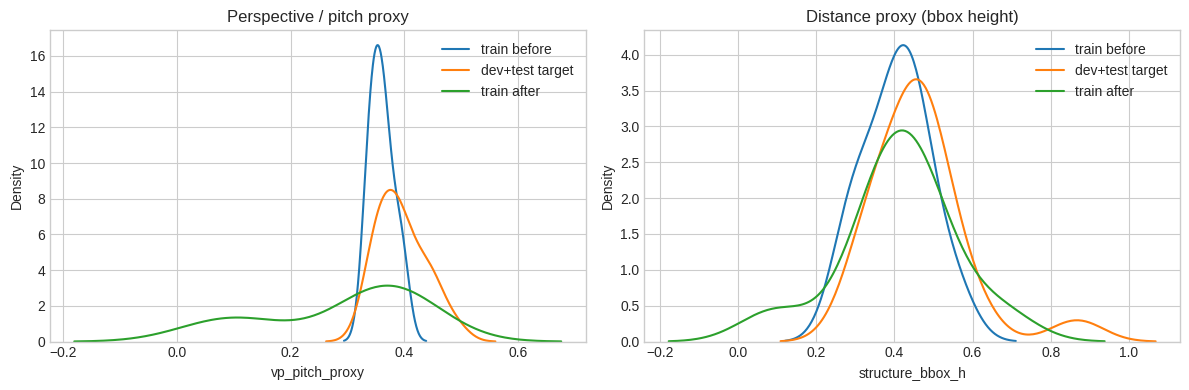

In [6]:
# Distribution check: before/target/after 분포를 겹쳐 보는 셀
plot_specs = [
    ('vp_pitch_proxy', 'after_vp_pitch_proxy', 'Perspective / pitch proxy'),
    ('structure_bbox_h', 'after_structure_bbox_h', 'Distance proxy (bbox height)'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (before_col, after_col, title) in zip(axes, plot_specs):
    sns.kdeplot(plan_df[before_col], ax=ax, label='train before', fill=False)
    sns.kdeplot(target_front[before_col], ax=ax, label='dev+test target', fill=False)
    sns.kdeplot(eval_df[after_col], ax=ax, label='train after', fill=False)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()

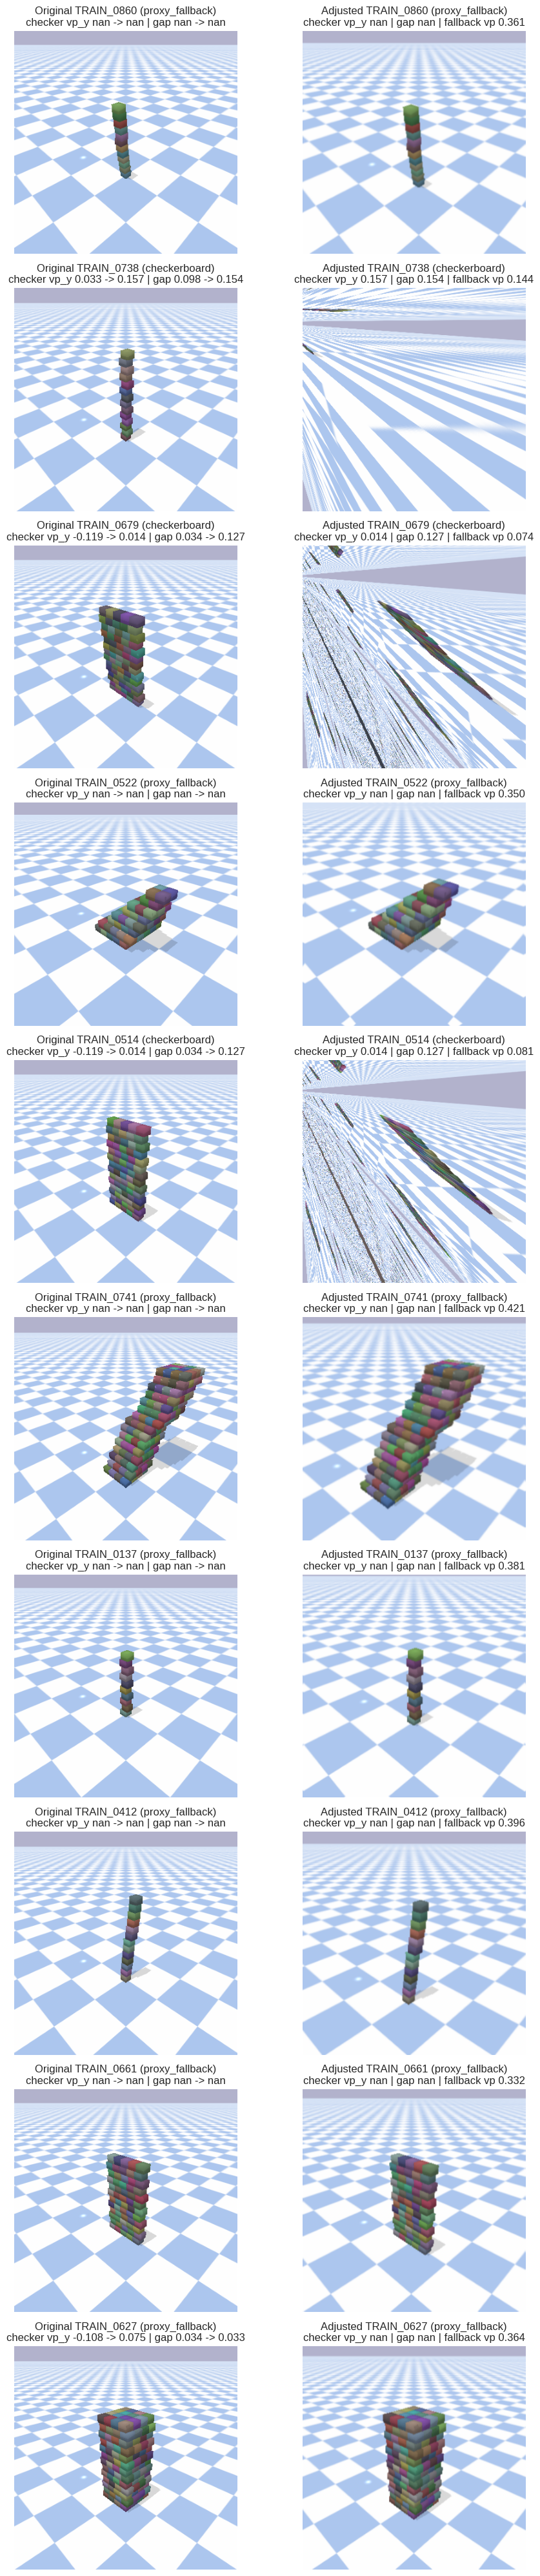

In [7]:
# Sample visualization: 원본/보정 이미지를 10개 샘플로 비교하는 마지막 셀
show_df = eval_df.sample(n=min(10, len(eval_df)), random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(len(show_df), 2, figsize=(10, 4 * len(show_df)))
if len(show_df) == 1:
    axes = [axes]

for idx, row in show_df.iterrows():
    orig = read_rgb(Path(row['image_path']))
    rendered_path = DEFAULT_RENDER_DIR / 'train' / row['sample_id'] / 'front.png'
    adj = read_rgb(rendered_path)

    axes[idx][0].imshow(orig)
    axes[idx][0].set_title(
        f"Original {row['sample_id']} ({row['method']})\n"
        f"checker vp_y {row['before_checker_vp_y_norm']:.3f} -> {row['target_checker_vp_y_norm']:.3f} | "
        f"gap {row['before_checker_bottom_gap_norm']:.3f} -> {row['target_checker_bottom_gap_norm']:.3f}"
    )
    axes[idx][0].axis('off')

    axes[idx][1].imshow(adj)
    axes[idx][1].set_title(
        f"Adjusted {row['sample_id']} ({row['method']})\n"
        f"checker vp_y {row['after_checker_vp_y_norm']:.3f} | gap {row['after_checker_bottom_gap_norm']:.3f} | "
        f"fallback vp {row['after_vp_pitch_proxy']:.3f}"
    )
    axes[idx][1].axis('off')

plt.tight_layout()